### Practice Quiz

#### Part 1

Read in the cleaned version of the Amazon laptop dataset found in `amazon_laptop_cleaned.csv`. Create dummy variables for the `colour_new` variable.

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/amazon_laptop_cleaned.csv")

df = pd.get_dummies(data=df, columns=["colour_new"], drop_first=True, dtype="int")
df.head()

,rating,total_rating,price,offer,brand,screen_size,hard_disk_size,ram,graphics_card,colour_new_Blue,colour_new_Grey,colour_new_Other,colour_new_Silver
0,4.3,63.0,85990.0,-28.0,Lenovo,14.0,512.0,16.0,Integrated,0,1,0,0
1,4.0,313.0,38000.0,-27.0,Lenovo,15.6,512.0,16.0,Integrated,0,1,0,0
2,3.1,62.0,16990.0,-60.0,Neopticon,14.1,128.0,4.0,Integrated,0,1,0,0
3,3.9,2071.0,24490.0,-38.0,acer,15.6,512.0,16.0,Integrated,0,1,0,0
4,4.0,48.0,99990.0,-17.0,ASUS,16.0,512.0,16.0,Integrated,0,0,0,0


#### Part 2

Fit a multiple linear regression model using `offer` and the dummy variables for `colour_new` as predictor variables and the log of `price` as a response variable.

Log the price 

In [14]:
df["log_price"] = np.log(df["price"])

In [15]:
from sklearn.linear_model import LinearRegression
mlr_model = LinearRegression()

x_mlr = df[["offer", "colour_new_Blue", "colour_new_Grey", "colour_new_Other", "colour_new_Silver"]]
y = df["log_price"]
mlr_model.fit(x_mlr, y)


LinearRegression()

#### Part 3

Print out the intercept and coefficients for the model fit in Part 2.

In [16]:
print("Intercept:", mlr_model.intercept_)
print("Slope:", mlr_model.coef_)

Intercept: 12.362807425284267
Slope: [ 0.0311645  -0.73842571 -0.52125084 -0.16289393 -0.63136638]


#### Part 4

Get predictions for the response variable using the model fit in Part 2 and then compute the RMSE.

In [19]:
from sklearn.metrics import root_mean_squared_error, r2_score

mlr_pred = mlr_model.predict(x_mlr)

print("MLR RMSE:", root_mean_squared_error(mlr_pred, y))


MLR RMSE: 0.49593430535720096


#### Part 5

Create a residual scatter plot of the predicted values on the x-axis and the residuals on the y-axis.

Text(0, 0.5, 'Residuals')

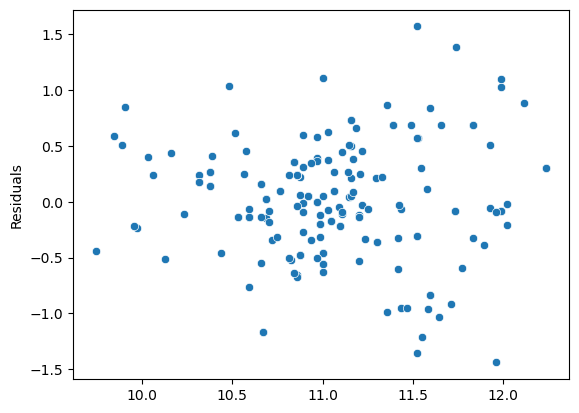

In [20]:
resid = y - mlr_pred

sns.scatterplot(data=df, x=mlr_pred, y=resid).set_ylabel("Residuals")

#### Part 6

Does there appear to be a violation of linearity for this model?

No there is no violation of linearity of the model appearing because the data is scattered randomly with no clear pattern